# Setup
Load necessary packages and download data

In [1]:
# # Only need to run these once (uncomment if needed)
# install.packages("foreign")
# install.packages("devtools")
# install.packages("tidyverse")
# install.packages("readr")
# install.packages("readxl")
# install.packages("haven")
# install.packages("dplyr")
# install.packages("gtsummary")
# isntall.packages("gt")
# install.packages("stringr")
# install.packages("survey")

# # Run these every time you restart R:
library(foreign)
library(devtools)
library(tidyverse)
library(readr)
library(readxl)
library(haven)
library(dplyr)
library(gtsummary)
library(gt)
library(stringr)
library(survey)

# only run once if needed
# install_github("sshrestha274/meps_r_pkg/MEPS")

library(MEPS)

Loading required package: usethis
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors
Loading required package: grid
Loading required package: Matrix

Attaching package: ‘Matrix’

The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack

Loading required package: survival

Attaching package: ‘survey’

The following object is masked from ‘package:graphics’:

    dotchart



In [2]:
# Load MEPS data for a single year and return a named list: fyc, cond, rx
load_meps_year <- function(year) {
  short_year <- substr(year, 3, 4)
  
  perwt  <- paste0("PERWT",  short_year, "F")
  ttlp   <- paste0("TTLP",   short_year, "X")
  povcat <- paste0("POVCAT", short_year)
  inscov <- paste0("INSCOV", short_year)
  insurc <- paste0("INSURC", short_year)
  totslf <- paste0("TOTSLF", short_year)
  obtotv <- paste0("OBTOTV", short_year)
  optotv <- paste0("OPTOTV", short_year)
  ipdis  <- paste0("IPDIS",  short_year)
  ipngtd <- paste0("IPNGTD", short_year)
  rxtot  <- paste0("RXTOT",  short_year)
  ertot  <- paste0("ERTOT",  short_year)
  
  vars_to_keep <- c(
    "DUPERSID", "PANEL", "VARSTR", "VARPSU", perwt, ttlp,
    "SEX", "AGE53X", "RACETHX", "MARRY53X", "REGION53",
    "EDUYRDG", "EDUCYR", povcat,
    "PCS42", "MCS42", "VPCS42", "VMCS42",
    "HAVEUS42", inscov, insurc, "MCAID53X",
    totslf, obtotv, optotv, ipdis, ipngtd, rxtot, ertot
  )
  
  fyc <- read_MEPS(year = year, type = "FYC") %>%
    select(any_of(vars_to_keep)) %>%
    rename(
      PERWT  = all_of(perwt),
      TTLP   = all_of(ttlp),
      POVCAT = all_of(povcat),
      INSCOV = all_of(inscov),
      TOTSLF = all_of(totslf),
      OBTOTV = all_of(obtotv),
      OPTOTV = all_of(optotv),
      IPDIS  = all_of(ipdis),
      IPNGTD = all_of(ipngtd),
      RXTOT  = all_of(rxtot),
      ERTOT  = all_of(ertot)
    )
  
  cond <- read_MEPS(year = year, type = "COND")
  
  rx <- read_MEPS(year = year, type = "RX")
  
  link <- read_MEPS(year = year, type = "CLNK")
  
  list(fyc = fyc, cond = cond, rx = rx, link = link)

}

save_all_years <- function(years = 2017:2023, out_file = file.path("data", "meps_all_years.rds")) {
  if (!dir.exists("data")) dir.create("data", recursive = TRUE)
  
  all_data <- list()
  for (yr in years) {
    d <- load_meps_year(yr)
    suffix <- paste0("_", yr)
    all_data[[paste0("fyc", suffix)]]  <- d$fyc
    all_data[[paste0("cond", suffix)]] <- d$cond
    all_data[[paste0("rx", suffix)]]   <- d$rx
    all_data[[paste0("link", suffix)]] <- d$link
  }
  
  saveRDS(all_data, file = out_file)
  invisible(out_file)
}

In [3]:
# Save the MEPS data into an accessible format

# save_all_years()

# Exploratory data analysis
Understand the data structure, identify patterns, and detect outliers

In [4]:
all_data <- readRDS(file.path("data", "meps_all_years.rds"))

for (i in 1:7) {
  assign(paste0("fyc_", 2016 + i), all_data[[paste0("fyc_", 2016 + i)]])
  assign(paste0("cond_", 2016 + i), all_data[[paste0("cond_", 2016 + i)]])
  assign(paste0("rx_", 2016 + i), all_data[[paste0("rx_", 2016 + i)]])
  assign(paste0("link_", 2016 + i), all_data[[paste0("link_", 2016 + i)]])
}

rm(all_data)
gc()

            used   (Mb) gc trigger   (Mb) limit (Mb)  max used   (Mb)
Ncells   9560687  510.6   16959214  905.8         NA   9814483  524.2
Vcells 195913995 1494.8  274274000 2092.6      16384 196295145 1497.7

## Prevalence of ADHD

In [5]:
years <- 2017:2023

adhd_results <- purrr::map_dfr(years, function(yr) {
  cond_adhd <- get(paste0("cond_", yr)) %>%
    filter(ICD10CDX == "F90") %>%
    mutate(adhd = 1) %>%
    distinct(DUPERSID, .keep_all = TRUE)

  merged <- get(paste0("fyc_", yr)) %>%
    left_join(cond_adhd, by = "DUPERSID", suffix = c("", "_cond")) %>%
    select(-ends_with("_cond")) %>%
    mutate(adhd = ifelse(is.na(adhd), 0, 1)) %>% 
    mutate(one = 1)

  design <- svydesign(
    id = ~VARPSU,
    strata = ~VARSTR,
    weights = ~PERWT,
    data = merged,
    nest = TRUE
  )

  total_obj <- svytotal(~adhd, design, na.rm = TRUE)
  mean_obj  <- svymean(~adhd, design, na.rm = TRUE)
  all_total <- svytotal(~one, design, na.rm = TRUE)

  tibble(
    year = yr,
    adhd_total = as.numeric(coef(total_obj)),
    adhd_total_se = as.numeric(SE(total_obj)),
    adhd_prevalence = as.numeric(coef(mean_obj)),
    adhd_prevalence_se = as.numeric(SE(mean_obj)),
    total_population = as.numeric(coef(all_total)),
    total_population_se = as.numeric(SE(all_total))
  )
})

adhd_results

# A tibble: 7 × 7
   year adhd_total adhd_total_se adhd_prevalence adhd_prevalence_se
  <int>      <dbl>         <dbl>           <dbl>              <dbl>
1  2017   8657153.       495695.          0.0267            0.00138
2  2018   8695818.       556378.          0.0266            0.00155
3  2019   8272391.       503280.          0.0253            0.00133
4  2020   8331132.       544532.          0.0254            0.00148
5  2021   9037563.       632449.          0.0273            0.00151
6  2022  11062755.       720481.          0.0332            0.00174
7  2023  11185407.       718525.          0.0334            0.00191
# ℹ 2 more variables: total_population <dbl>, total_population_se <dbl>

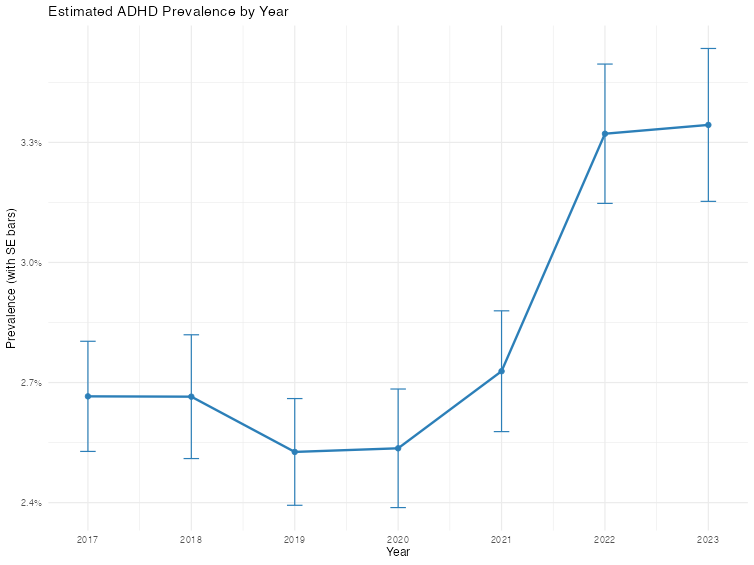

In [37]:
ggplot(adhd_results, aes(x = year, y = adhd_prevalence)) +
  geom_line(color = "#2C7FB8", linewidth = 1) +
  geom_point(color = "#2C7FB8", size = 2) +
  geom_errorbar(
    aes(
      ymin = adhd_prevalence - adhd_prevalence_se,
      ymax = adhd_prevalence + adhd_prevalence_se
    ),
    width = 0.15,
    color = "#2C7FB8"
  ) +
  scale_x_continuous(breaks = adhd_results$year) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 0.1)) +
  labs(
    title = "Estimated ADHD Prevalence by Year",
    x = "Year",
    y = "Prevalence (with SE bars)"
  ) +
  theme_minimal()